In [ ]:
import sys
print(sys.executable)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("ready")

In [ ]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)

df.head()

In [26]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
 13  quality_label         6497 non-null   str    
dtypes: float64(11), int64(1), str(2)
memory usage: 710.7 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


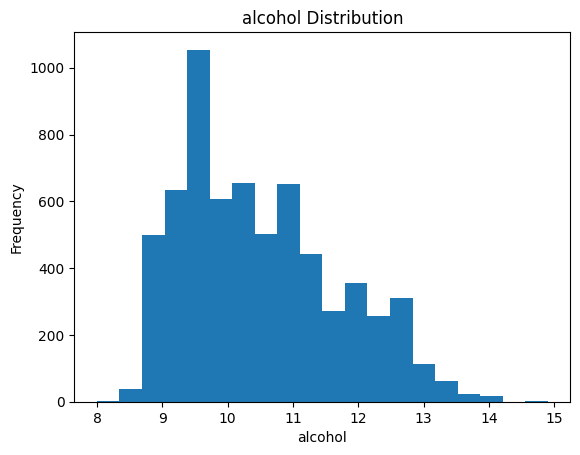

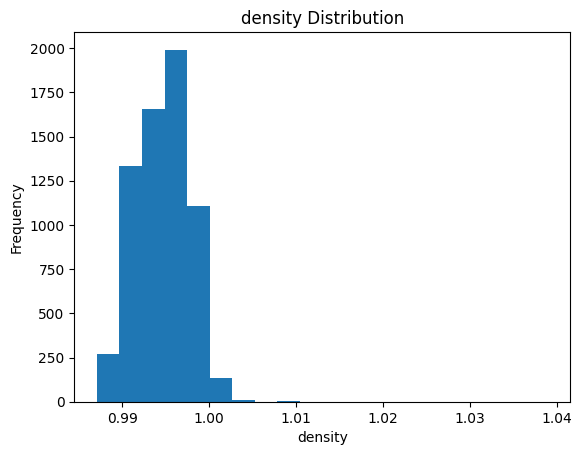

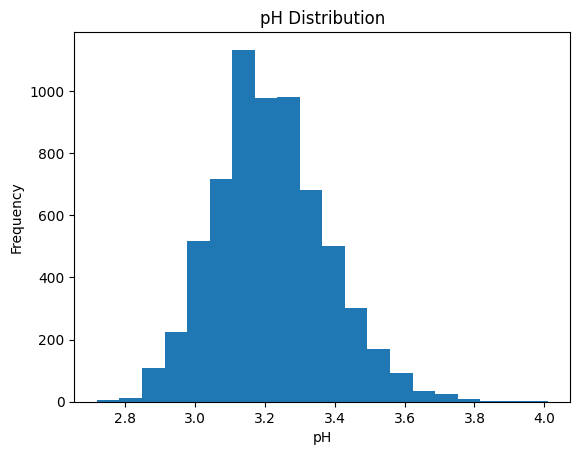

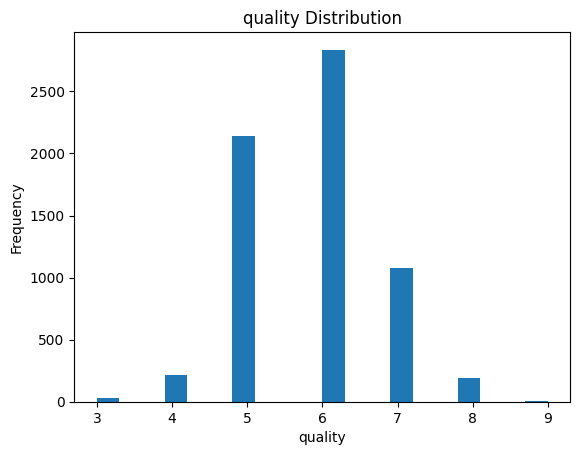

In [27]:
hist_cols = ["alcohol", "density", "pH", "quality"]

for col in hist_cols:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

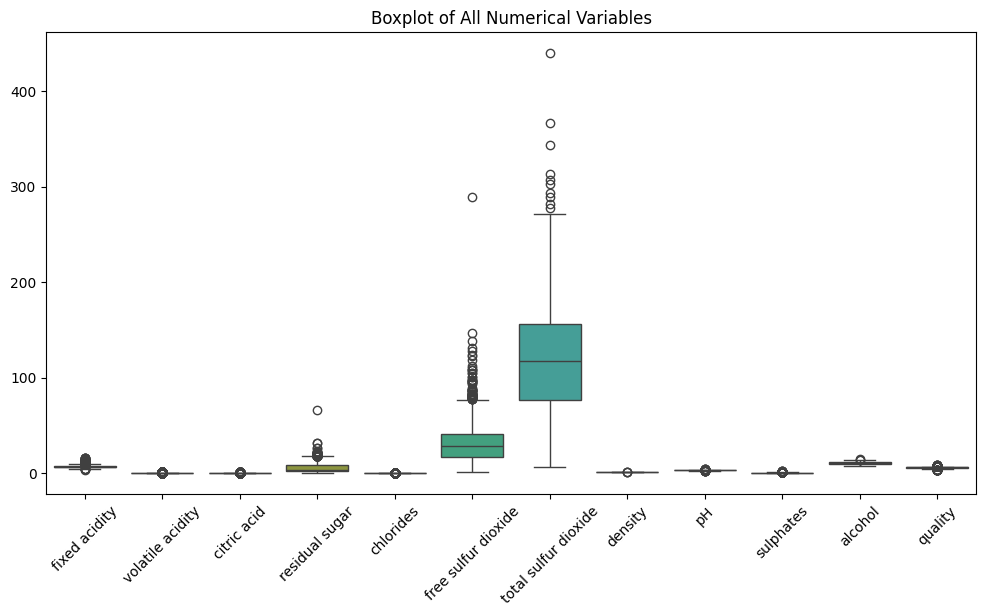

In [28]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title("Boxplot of All Numerical Variables")
plt.show()

In [ ]:
sns.pairplot(df.select_dtypes(include=np.number))

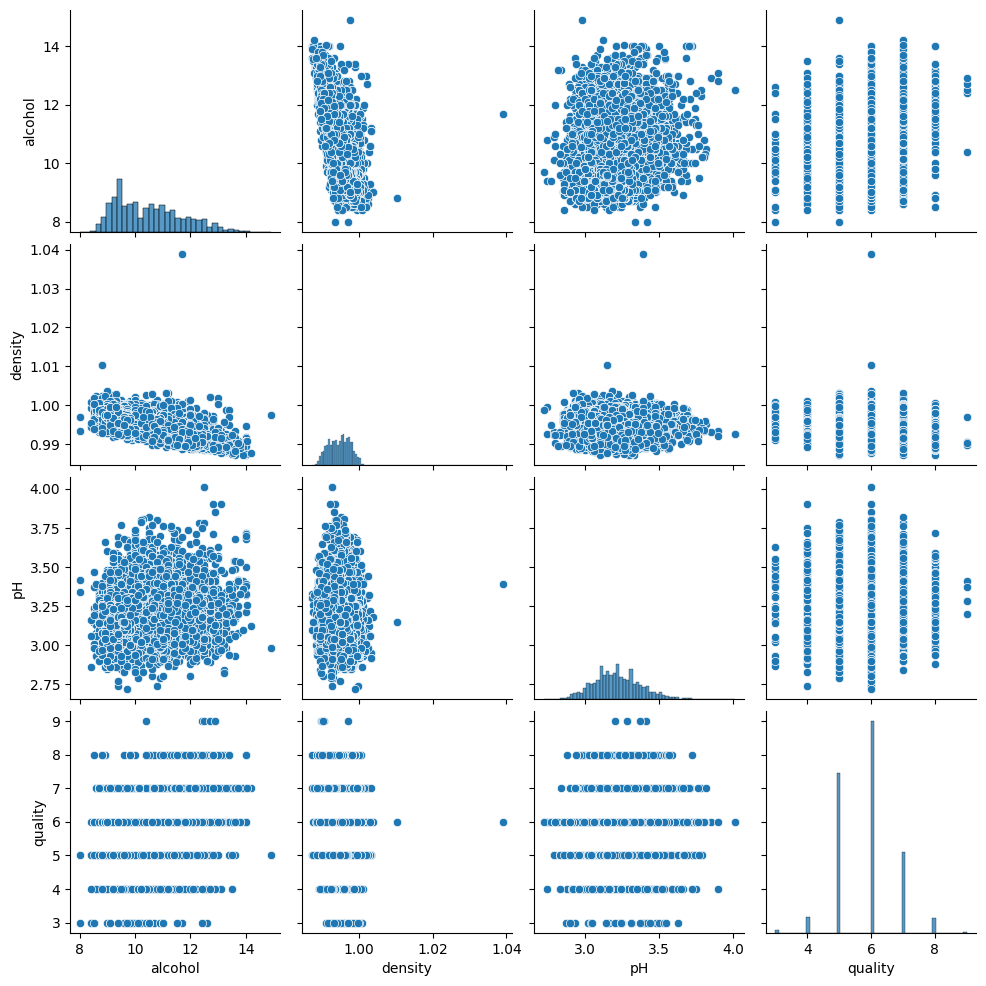

In [23]:
subset = ["alcohol", "density", "pH", "quality"]

sns.pairplot(df[subset])
plt.show()

In [ ]:
df["quality_label"] = np.where(df["quality"] >= 7, "high", "low")
df.head()

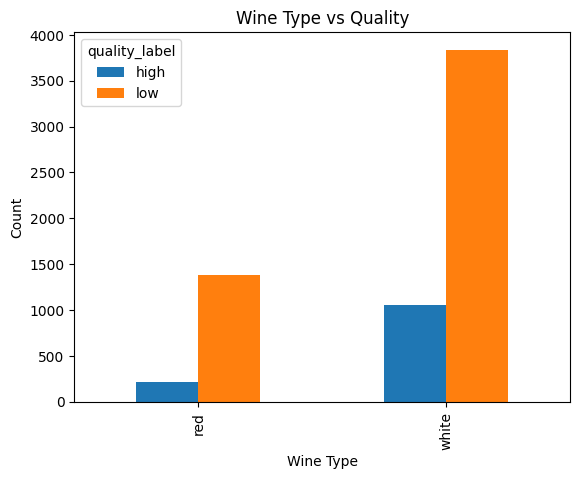

In [25]:
pd.crosstab(df["wine_type"], df["quality_label"]).plot(kind="bar")
plt.title("Wine Type vs Quality")
plt.xlabel("Wine Type")
plt.ylabel("Count")
plt.show()

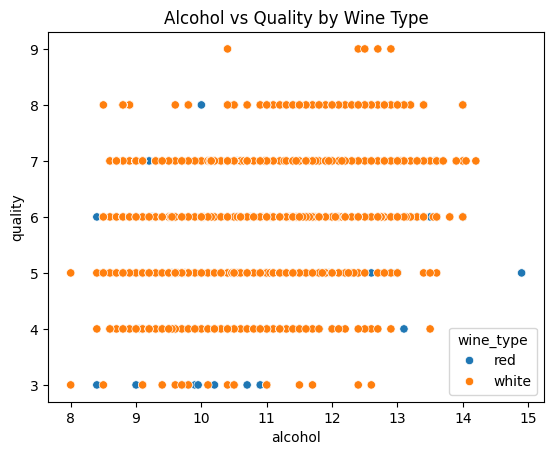

In [24]:
sns.scatterplot(x="alcohol", y="quality", hue="wine_type", data=df)
plt.title("Alcohol vs Quality by Wine Type")
plt.show()